# Final Project Step 2: Initial Data Assessment Notebook # 

Due: Friday, April 17 at 5:00 PM | 20 pts | Assignment

Upload your dataset and a .ipynb notebook. The notebook should run without errors and include:

Load the data with an explanatory note.

Review column headers and provide initial insights (min, max, mean, data types).

2-3 informative graphs or tables exploring your questions.

A written reflection on what you found, any cleaning needed, and next steps.

Submit your .ipynb file and your dataset (.csv).

## Data Setup ##

In [2]:
import sqlite3
import pandas as pd
import tabulate as t
import matplotlib.pyplot as plt


county_median26 = pd.read_csv('fy2026_fmr_50.csv') #data by county; median rent for 0-4 bedrooms (2026)
area_median26 = pd.read_csv('area_fy2026_fmr_50.csv') #data by area; median rent for 0-4 bedrooms (2026)
county_median25 = pd.read_csv('fy2025_fmr_50.csv') #data by county; median rent for 0-4 bedrooms (2025)
area_median25 = pd.read_csv('area_fy2025_fmr_50.csv') #data by area; median rent for 0-4 bedrooms (2025)

print(f"Median County Rent for 2026: {len(county_median26)} rows, columns: {list(county_median26.columns)}")
print(f"Median Area Rent for 2026: {len(area_median26)} rows, columns: {list(area_median26.columns)}")
print(f"Median County Rent for 2025: {len(county_median25)} rows, columns: {list(county_median25.columns)}")
print(f"Median Area Rent for 2025: {len(area_median25)} rows, columns: {list(area_median25.columns)}")

conn = sqlite3.connect(':memory:')

county_median26.to_sql('county26', conn, index=False)
area_median26.to_sql('area26', conn, index=False)
county_median25.to_sql('county25', conn, index=False)
area_median25.to_sql('area25', conn, index=False)

Median County Rent for 2026: 4764 rows, columns: ['state_code', 'county_code', 'county_sub_code', 'cntyname', 'town_name', 'hud_areaname', 'fips2025', 'rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4', 'hud_area_code', 'pop2023', 'state_alpha']
Median Area Rent for 2026: 2605 rows, columns: ['hud_area_code', 'hud_areaname', 'rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4']
Median County Rent for 2025: 4764 rows, columns: ['state_code', 'county_code', 'county_sub_code', 'cntyname', 'town_name', 'hud_areaname', 'fips2010', 'rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4', 'hud_area_code', 'pop2020', 'state_alpha']
Median Area Rent for 2025: 2601 rows, columns: ['hud_area_code', 'hud_areaname', 'rent_50_0', 'rent_50_1', 'rent_50_2', 'rent_50_3', 'rent_50_4']


2601

## Data Discovery (2025)


### What are the counties and areas with the cheapest rent (based on amount of bedrooms)? 

In [75]:
# 10 cheapest studios (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_0
                  FROM county25
                  ORDER BY rent_50_0 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest studios (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_0
                  FROM area25
                  ORDER BY rent_50_0 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the lowest median rent for studios:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the lowest median rent for stuios: {t.tabulate(area)}")


The 10 counties (2025) with the lowest median rent for studios:, -  ----------------------  ---
0  Coamo Municipio         436
1  Culebra Municipio       436
2  Jayuya Municipio        436
3  Maricao Municipio       436
4  Salinas Municipio       436
5  Santa Isabel Municipio  436
6  Vieques Municipio       436
7  Arroyo Municipio        437
8  Guayama Municipio       437
9  Patillas Municipio      437
-  ----------------------  ---
The 10 areas (2025) with the lowest median rent for stuios: -  --------------------------------------------  ---
0  Puerto Rico HUD Nonmetro Area                 436
1  Guayama, PR MSA                               437
2  Barranquitas-Aibonito, PR HUD Metro FMR Area  443
3  San German, PR MSA                            457
4  Yauco, PR MSA                                 469
5  Arecibo, PR MSA                               488
6  Caguas, PR HUD Metro FMR Area                 513
7  Aguadilla-Isabela, PR MSA                     515
8  Marion County, AL      

In [76]:
# 10 cheapest 1 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_1
                  FROM county25
                  ORDER BY rent_50_1 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 1 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_1
                  FROM area25
                  ORDER BY rent_50_1 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the lowest median rent for 1 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the lowest median rent for 1 bedrooms: {t.tabulate(area)}")


The 10 counties (2025) with the lowest median rent for 1 bedrooms:, -  ----------------------  ---
0  Arroyo Municipio        440
1  Guayama Municipio       440
2  Patillas Municipio      440
3  Aibonito Municipio      443
4  Barranquitas Municipio  443
5  Ciales Municipio        443
6  Orocovis Municipio      443
7  Coamo Municipio         452
8  Culebra Municipio       452
9  Jayuya Municipio        452
-  ----------------------  ---
The 10 areas (2025) with the lowest median rent for 1 bedrooms: -  --------------------------------------------  ---
0  Guayama, PR MSA                               440
1  Barranquitas-Aibonito, PR HUD Metro FMR Area  443
2  Puerto Rico HUD Nonmetro Area                 452
3  San German, PR MSA                            459
4  Yauco, PR MSA                                 487
5  Arecibo, PR MSA                               491
6  Caguas, PR HUD Metro FMR Area                 517
7  Aguadilla-Isabela, PR MSA                     518
8  Mayagüez, PR MSA

In [78]:
# 10 cheapest 2 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_2
                  FROM county25
                  ORDER BY rent_50_2 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 2 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_2
                  FROM area25
                  ORDER BY rent_50_2 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the lowest median rent for 2 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the lowest median rent for 2 bedrooms: {t.tabulate(area)}")

The 10 counties (2025) with the lowest median rent for 2 bedrooms:, -  ----------------------  ---
0  Coamo Municipio         501
1  Culebra Municipio       501
2  Jayuya Municipio        501
3  Maricao Municipio       501
4  Salinas Municipio       501
5  Santa Isabel Municipio  501
6  Vieques Municipio       501
7  Aibonito Municipio      510
8  Barranquitas Municipio  510
9  Ciales Municipio        510
-  ----------------------  ---
The 10 areas (2025) with the lowest median rent for 2 bedrooms: -  --------------------------------------------  ---
0  Puerto Rico HUD Nonmetro Area                 501
1  Barranquitas-Aibonito, PR HUD Metro FMR Area  510
2  Guayama, PR MSA                               515
3  Yauco, PR MSA                                 539
4  Arecibo, PR MSA                               561
5  San German, PR MSA                            572
6  Aguadilla-Isabela, PR MSA                     592
7  Mayagüez, PR MSA                              604
8  Caguas, PR HUD M

In [ ]:
# 10 cheapest 3 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_3
                  FROM county25
                  ORDER BY rent_50_3 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 3 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_3
                  FROM area25
                  ORDER BY rent_50_3 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the lowest median rent for 3 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the lowest median rent for 3 bedrooms: {t.tabulate(area)}")

The 10 counties (2026) with the lowest median rent for 3 bedrooms:, -  -----------------------  ---
0  Aibonito Municipio       644
1  Barranquitas Municipio   644
2  Ciales Municipio         644
3  Orocovis Municipio       644
4  Arroyo Municipio         653
5  Guayama Municipio        653
6  Patillas Municipio       653
7  Cabo Rojo Municipio      688
8  Lajas Municipio          688
9  Sabana Grande Municipio  688
-  -----------------------  ---
The 10 areas (2026) with the lowest median rent for 3 bedrooms: -  --------------------------------------------  ---
0  Barranquitas-Aibonito, PR HUD Metro FMR Area  644
1  Guayama, PR MSA                               653
2  San Germán, PR HUD Metro FMR Area             688
3  Puerto Rico HUD Nonmetro Area                 693
4  Aguadilla, PR MSA                             716
5  Yauco, PR HUD Metro FMR Area                  721
6  Arecibo, PR MSA                               737
7  Mayagüez, PR HUD Metro FMR Area               747
8  Faja

In [ ]:
# 10 cheapest 4 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_4
                  FROM county25
                  ORDER BY rent_50_4 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 4 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_4
                  FROM area25
                  ORDER BY rent_50_4 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the lowest median rent for 4 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the lowest median rent for 4 bedrooms: {t.tabulate(area)}")

The 10 counties (2026) with the lowest median rent for 4 bedrooms:, -  ----------------------  ---
0  Arroyo Municipio        655
1  Guayama Municipio       655
2  Patillas Municipio      655
3  Aibonito Municipio      729
4  Barranquitas Municipio  729
5  Ciales Municipio        729
6  Orocovis Municipio      729
7  Guayanilla Municipio    731
8  Peñuelas Municipio      731
9  Yauco Municipio         731
-  ----------------------  ---
The 10 areas (2026) with the lowest median rent for 4 bedrooms: -  --------------------------------------------  ---
0  Guayama, PR MSA                               655
1  Barranquitas-Aibonito, PR HUD Metro FMR Area  729
2  Yauco, PR HUD Metro FMR Area                  731
3  San Germán, PR HUD Metro FMR Area             732
4  Puerto Rico HUD Nonmetro Area                 752
5  Aguadilla, PR MSA                             796
6  Arecibo, PR MSA                               829
7  Fajardo, PR HUD Metro FMR Area                864
8  Mayagüez, PR HUD

### What are the counties and areas with the most expensive rent (based on amount of bedrooms)?

In [ ]:
# 10 expensive studios (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_0
                  FROM county25
                  ORDER BY rent_50_0 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive studios (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_0
                  FROM area25
                  ORDER BY rent_50_0 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the highest median rent for studios:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the highest median rent for stuios: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for studios:, -  --------------------  ----
0  Santa Cruz County     3310
1  Orange County         2874
2  Santa Clara County    2853
3  Marin County          2808
4  San Francisco County  2808
5  San Mateo County      2808
6  Bronx County          2777
7  Kings County          2777
8  New York County       2777
9  Putnam County         2777
-  --------------------  ----
The 10 areas (2026) with the highest median rent for stuios: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         3310
1  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        2874
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  2853
3  San Francisco, CA HUD Metro FMR Area                   2808
4  New York, NY HUD Metro FMR Area                        2777
5  Santa Maria-Santa Barbara, CA MSA                      2752
6  Jersey City, NJ HUD Metro FMR Area                     2636
7  Nantuc

In [ ]:
# 10 expensive 1 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_1
                  FROM county25
                  ORDER BY rent_50_1 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 1 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_1
                  FROM area25
                  ORDER BY rent_50_1 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the highest median rent for 1 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the highest median rent for 1 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 1 bedroom:, -  --------------------  ----
0  Santa Cruz County     3434
1  Marin County          3364
2  San Francisco County  3364
3  San Mateo County      3364
4  Santa Clara County    3246
5  Santa Barbara County  3073
6  Orange County         2943
7  Bronx County          2916
8  Kings County          2916
9  New York County       2916
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 1 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         3434
1  San Francisco, CA HUD Metro FMR Area                   3364
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  3246
3  Santa Maria-Santa Barbara, CA MSA                      3073
4  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        2943
5  New York, NY HUD Metro FMR Area                        2916
6  Jersey City, NJ HUD Metro FMR Area                     2692
7  S

In [ ]:
# 10 expensive 2 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_2
                  FROM county25
                  ORDER BY rent_50_2 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 2 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_2
                  FROM area25
                  ORDER BY rent_50_2 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the highest median rent for 2 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the highest median rent for 2 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 2 bedroom:, -  --------------------  ----
0  Santa Cruz County     4388
1  Marin County          4072
2  San Francisco County  4072
3  San Mateo County      4072
4  Santa Clara County    3791
5  Santa Barbara County  3496
6  Orange County         3468
7  Nantucket County      3324
8  San Diego County      3255
9  Bronx County          3196
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 2 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         4388
1  San Francisco, CA HUD Metro FMR Area                   4072
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  3791
3  Santa Maria-Santa Barbara, CA MSA                      3496
4  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        3468
5  Nantucket County, MA                                   3324
6  San Diego-Chula Vista-Carlsbad, CA MSA                 3255
7  N

In [ ]:
# 10 expensive 3 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_3
                  FROM county25
                  ORDER BY rent_50_3 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 3 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_3
                  FROM area25
                  ORDER BY rent_50_3 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the highest median rent for 3 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the highest median rent for 3 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 3 bedroom:, -  --------------------  ----
0  Santa Cruz County     5599
1  Marin County          5201
2  San Francisco County  5201
3  San Mateo County      5201
4  Santa Clara County    5009
5  Orange County         4708
6  Santa Barbara County  4560
7  Nantucket County      4389
8  San Diego County      4336
9  Sonoma County         4116
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 3 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         5599
1  San Francisco, CA HUD Metro FMR Area                   5201
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  5009
3  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        4708
4  Santa Maria-Santa Barbara, CA MSA                      4560
5  Nantucket County, MA                                   4389
6  San Diego-Chula Vista-Carlsbad, CA MSA                 4336
7  S

In [ ]:
# 10 expensive 4 bedroom (counties 2025)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_1
                  FROM county25
                  ORDER BY rent_50_1 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 4 bedroom (areas 2025)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_4
                  FROM area25
                  ORDER BY rent_50_4 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2025) with the highest median rent for 4 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2025) with the highest median rent for 4 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 4 bedroom:, -  --------------------  ----
0  Santa Cruz County     3434
1  Marin County          3364
2  San Francisco County  3364
3  San Mateo County      3364
4  Santa Clara County    3246
5  Santa Barbara County  3073
6  Orange County         2943
7  Bronx County          2916
8  Kings County          2916
9  New York County       2916
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 4 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         5892
1  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        5622
2  Nantucket County, MA                                   5571
3  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  5453
4  San Francisco, CA HUD Metro FMR Area                   5391
5  San Diego-Chula Vista-Carlsbad, CA MSA                 5255
6  Santa Maria-Santa Barbara, CA MSA                      5200
7  O

### What is the average median rent for counties vs areas? ###

In [ ]:
# The avaerage median rent based on by county data from 2025

county = pd.read_sql_query("""
                           SELECT
                                AVG(rent_50_0) AS avg_studio,
                                AVG(rent_50_1) AS avg_1bed,
                                AVG(rent_50_2) AS avg_2bed,
                                AVG(rent_50_3) AS avg_3bed,
                                AVG(rent_50_4) AS avg_4bed                           
                           FROM county25
                           """, conn)

print("The average median rent based on the by county data from 2025:")
county



The average median rent based on the by county data from 2026:


,avg_studio,avg_1bed,avg_2bed,avg_3bed,avg_4bed
0,1078.95529,1158.615659,1434.450672,1847.770571,2095.793451


In [ ]:
# The averag median rent based on by area data from 2025

area = pd.read_sql_query("""
                           SELECT
                                AVG(rent_50_0) AS avg_studio,
                                AVG(rent_50_1) AS avg_1bed,
                                AVG(rent_50_2) AS avg_2bed,
                                AVG(rent_50_3) AS avg_3bed,
                                AVG(rent_50_4) AS avg_4bed                           
                           FROM area25
                           """, conn)

print("The average median rent based on the by area data from 2025:")
area

The average median rent based on the by area data from 2026:


,avg_studio,avg_1bed,avg_2bed,avg_3bed,avg_4bed
0,872.811132,938.457198,1164.563916,1515.057582,1740.537044


### What are the counties with the largest and smallest populations?

In [ ]:
# 10 Largest population 2025

large = pd.read_sql_query("""
                          SELECT cntyname, pop2023
                          FROM county25
                          ORDER BY pop2023 DESC
                          LIMIT 10
                          """, conn)

large

,cntyname,pop2023
0,Los Angeles County,9936690
1,Cook County,5225367
2,Harris County,4726177
3,Maricopa County,4430871
4,San Diego County,3289701
5,Orange County,3175227
6,Miami-Dade County,2688237
7,Kings County,2679620
8,Dallas County,2604053
9,Riverside County,2429487


In [ ]:
# 10 Smallest population 2025

small = pd.read_sql_query("""
                          SELECT cntyname, state_alpha, pop2023
                          FROM county25
                          WHERE pop2023 > 0 
                          ORDER BY pop2023 ASC
                          LIMIT 10
                          """, conn)
# had to add a WHERE because all the counties first given had no population listed
small

,cntyname,state_alpha,pop2023
0,Aroostook County,ME,5
1,Coos County,NH,5
2,Essex County,VT,5
3,Aroostook County,ME,6
4,Aroostook County,ME,7
5,Coos County,NH,8
6,Coos County,NH,8
7,Franklin County,ME,9
8,Piscataquis County,ME,9
9,Washington County,ME,10


### What are the average rent by states?

In [ ]:
pd.read_sql_query(""" 
                  SELECT state_alpha, state_code,
                        AVG(rent_50_0) AS avg_studio,
                        AVG(rent_50_1) AS avg_1bed,
                        AVG(rent_50_2) AS avg_2bed,
                        AVG(rent_50_3) AS avg_3bed,
                        AVG(rent_50_4) AS avg_4bed                  
                  FROM county25
                  GROUP BY state_alpha
                  ORDER BY state_code ASC
                  """, conn)

,state_alpha,state_code,avg_studio,avg_1bed,avg_2bed,avg_3bed,avg_4bed
0,AL,1,765.194030,825.641791,1001.179104,1290.477612,1476.850746
1,AK,2,1142.900000,1286.200000,1579.733333,2090.066667,2479.733333
2,AZ,4,1130.800000,1236.533333,1525.333333,2029.400000,2316.933333
3,AR,5,724.693333,776.746667,975.826667,1281.293333,1452.133333
4,CA,6,1639.517241,1786.120690,2224.844828,2981.103448,3427.293103
5,CO,8,1171.906250,1257.312500,1547.609375,2016.187500,2357.031250
6,CT,9,1409.934911,1650.366864,2040.633136,2519.106509,2932.899408
7,DE,10,1319.666667,1369.666667,1708.666667,2180.000000,2513.666667
8,DC,11,2111.000000,2177.000000,2427.000000,3063.000000,3601.000000
9,FL,12,1316.388060,1408.910448,1658.119403,2142.746269,2457.641791


## Data Discovey (2026)

### What are the counties and areas with the cheapest rent in 2026 (based on amount of bedrooms)? 

In [ ]:
# 10 cheapest studios (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_0
                  FROM county26
                  ORDER BY rent_50_0 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest studios (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_0
                  FROM area26
                  ORDER BY rent_50_0 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the lowest median rent for studios:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the lowest median rent for stuios: {t.tabulate(area)}")


The 10 counties (2026) with the lowest median rent for studios:, -  -----------------------  ---
0  Arroyo Municipio         424
1  Guayama Municipio        424
2  Patillas Municipio       424
3  Cabo Rojo Municipio      425
4  Lajas Municipio          425
5  Sabana Grande Municipio  425
6  San Germán Municipio     425
7  Adjuntas Municipio       434
8  Coamo Municipio          434
9  Culebra Municipio        434
-  -----------------------  ---
The 10 areas (2026) with the lowest median rent for stuios: -  --------------------------------------------  ---
0  Guayama, PR MSA                               424
1  San Germán, PR HUD Metro FMR Area             425
2  Puerto Rico HUD Nonmetro Area                 434
3  Barranquitas-Aibonito, PR HUD Metro FMR Area  445
4  Arecibo, PR MSA                               460
5  Yauco, PR HUD Metro FMR Area                  460
6  Caguas, PR HUD Metro FMR Area                 490
7  Ponce, PR HUD Metro FMR Area                  503
8  Aguadilla, 

In [ ]:
# 10 cheapest 1 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_1
                  FROM county26
                  ORDER BY rent_50_1 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 1 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_1
                  FROM area26
                  ORDER BY rent_50_1 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the lowest median rent for 1 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the lowest median rent for 1 bedrooms: {t.tabulate(area)}")


The 10 counties (2026) with the lowest median rent for 1 bedrooms:, -  -----------------------  ---
0  Cabo Rojo Municipio      427
1  Lajas Municipio          427
2  Sabana Grande Municipio  427
3  San Germán Municipio     427
4  Arroyo Municipio         429
5  Guayama Municipio        429
6  Patillas Municipio       429
7  Aibonito Municipio       449
8  Barranquitas Municipio   449
9  Ciales Municipio         449
-  -----------------------  ---
The 10 areas (2026) with the lowest median rent for 1 bedrooms: -  --------------------------------------------  ---
0  San Germán, PR HUD Metro FMR Area             427
1  Guayama, PR MSA                               429
2  Barranquitas-Aibonito, PR HUD Metro FMR Area  449
3  Puerto Rico HUD Nonmetro Area                 454
4  Arecibo, PR MSA                               463
5  Yauco, PR HUD Metro FMR Area                  482
6  Caguas, PR HUD Metro FMR Area                 493
7  Aguadilla, PR MSA                             508
8  Ponc

In [ ]:
# 10 cheapest 2 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_2
                  FROM county26
                  ORDER BY rent_50_2 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 2 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_2
                  FROM area26
                  ORDER BY rent_50_2 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the lowest median rent for 2 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the lowest median rent for 2 bedrooms: {t.tabulate(area)}")

The 10 counties (2026) with the lowest median rent for 2 bedrooms:, -  --------------------  ---
0  Arroyo Municipio      487
1  Guayama Municipio     487
2  Patillas Municipio    487
3  Adjuntas Municipio    498
4  Coamo Municipio       498
5  Culebra Municipio     498
6  Guánica Municipio     498
7  Jayuya Municipio      498
8  Lares Municipio       498
9  Las Marías Municipio  498
-  --------------------  ---
The 10 areas (2026) with the lowest median rent for 2 bedrooms: -  --------------------------------------------  ---
0  Guayama, PR MSA                               487
1  Puerto Rico HUD Nonmetro Area                 498
2  Barranquitas-Aibonito, PR HUD Metro FMR Area  511
3  Yauco, PR HUD Metro FMR Area                  528
4  Arecibo, PR MSA                               537
5  San Germán, PR HUD Metro FMR Area             553
6  Ponce, PR HUD Metro FMR Area                  577
7  Mayagüez, PR HUD Metro FMR Area               581
8  Aguadilla, PR MSA                       

In [ ]:
# 10 cheapest 3 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_3
                  FROM county26
                  ORDER BY rent_50_3 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 3 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_3
                  FROM area26
                  ORDER BY rent_50_3 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the lowest median rent for 3 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the lowest median rent for 3 bedrooms: {t.tabulate(area)}")

The 10 counties (2026) with the lowest median rent for 3 bedrooms:, -  -----------------------  ---
0  Aibonito Municipio       644
1  Barranquitas Municipio   644
2  Ciales Municipio         644
3  Orocovis Municipio       644
4  Arroyo Municipio         653
5  Guayama Municipio        653
6  Patillas Municipio       653
7  Cabo Rojo Municipio      688
8  Lajas Municipio          688
9  Sabana Grande Municipio  688
-  -----------------------  ---
The 10 areas (2026) with the lowest median rent for 3 bedrooms: -  --------------------------------------------  ---
0  Barranquitas-Aibonito, PR HUD Metro FMR Area  644
1  Guayama, PR MSA                               653
2  San Germán, PR HUD Metro FMR Area             688
3  Puerto Rico HUD Nonmetro Area                 693
4  Aguadilla, PR MSA                             716
5  Yauco, PR HUD Metro FMR Area                  721
6  Arecibo, PR MSA                               737
7  Mayagüez, PR HUD Metro FMR Area               747
8  Faja

In [ ]:
# 10 cheapest 4 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_4
                  FROM county26
                  ORDER BY rent_50_4 ASC
                  LIMIT 10
                  """, conn)

# 10 cheapest 4 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_4
                  FROM area26
                  ORDER BY rent_50_4 ASC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the lowest median rent for 4 bedrooms:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the lowest median rent for 4 bedrooms: {t.tabulate(area)}")

The 10 counties (2026) with the lowest median rent for 4 bedrooms:, -  ----------------------  ---
0  Arroyo Municipio        655
1  Guayama Municipio       655
2  Patillas Municipio      655
3  Aibonito Municipio      729
4  Barranquitas Municipio  729
5  Ciales Municipio        729
6  Orocovis Municipio      729
7  Guayanilla Municipio    731
8  Peñuelas Municipio      731
9  Yauco Municipio         731
-  ----------------------  ---
The 10 areas (2026) with the lowest median rent for 4 bedrooms: -  --------------------------------------------  ---
0  Guayama, PR MSA                               655
1  Barranquitas-Aibonito, PR HUD Metro FMR Area  729
2  Yauco, PR HUD Metro FMR Area                  731
3  San Germán, PR HUD Metro FMR Area             732
4  Puerto Rico HUD Nonmetro Area                 752
5  Aguadilla, PR MSA                             796
6  Arecibo, PR MSA                               829
7  Fajardo, PR HUD Metro FMR Area                864
8  Mayagüez, PR HUD

### What are the counties and areas with the most expensive rent (based on amount of bedrooms)?

In [ ]:
# 10 expensive studios (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_0
                  FROM county26
                  ORDER BY rent_50_0 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive studios (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_0
                  FROM area26
                  ORDER BY rent_50_0 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the highest median rent for studios:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the highest median rent for stuios: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for studios:, -  --------------------  ----
0  Santa Cruz County     3310
1  Orange County         2874
2  Santa Clara County    2853
3  Marin County          2808
4  San Francisco County  2808
5  San Mateo County      2808
6  Bronx County          2777
7  Kings County          2777
8  New York County       2777
9  Putnam County         2777
-  --------------------  ----
The 10 areas (2026) with the highest median rent for stuios: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         3310
1  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        2874
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  2853
3  San Francisco, CA HUD Metro FMR Area                   2808
4  New York, NY HUD Metro FMR Area                        2777
5  Santa Maria-Santa Barbara, CA MSA                      2752
6  Jersey City, NJ HUD Metro FMR Area                     2636
7  Nantuc

In [ ]:
# 10 expensive 1 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_1
                  FROM county26
                  ORDER BY rent_50_1 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 1 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_1
                  FROM area26
                  ORDER BY rent_50_1 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the highest median rent for 1 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the highest median rent for 1 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 1 bedroom:, -  --------------------  ----
0  Santa Cruz County     3434
1  Marin County          3364
2  San Francisco County  3364
3  San Mateo County      3364
4  Santa Clara County    3246
5  Santa Barbara County  3073
6  Orange County         2943
7  Bronx County          2916
8  Kings County          2916
9  New York County       2916
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 1 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         3434
1  San Francisco, CA HUD Metro FMR Area                   3364
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  3246
3  Santa Maria-Santa Barbara, CA MSA                      3073
4  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        2943
5  New York, NY HUD Metro FMR Area                        2916
6  Jersey City, NJ HUD Metro FMR Area                     2692
7  S

In [ ]:
# 10 expensive 2 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_2
                  FROM county26
                  ORDER BY rent_50_2 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 2 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_2
                  FROM area26
                  ORDER BY rent_50_2 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the highest median rent for 2 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the highest median rent for 2 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 2 bedroom:, -  --------------------  ----
0  Santa Cruz County     4388
1  Marin County          4072
2  San Francisco County  4072
3  San Mateo County      4072
4  Santa Clara County    3791
5  Santa Barbara County  3496
6  Orange County         3468
7  Nantucket County      3324
8  San Diego County      3255
9  Bronx County          3196
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 2 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         4388
1  San Francisco, CA HUD Metro FMR Area                   4072
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  3791
3  Santa Maria-Santa Barbara, CA MSA                      3496
4  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        3468
5  Nantucket County, MA                                   3324
6  San Diego-Chula Vista-Carlsbad, CA MSA                 3255
7  N

In [ ]:
# 10 expensive 3 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_3
                  FROM county26
                  ORDER BY rent_50_3 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 3 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_3
                  FROM area26
                  ORDER BY rent_50_3 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the highest median rent for 3 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the highest median rent for 3 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 3 bedroom:, -  --------------------  ----
0  Santa Cruz County     5599
1  Marin County          5201
2  San Francisco County  5201
3  San Mateo County      5201
4  Santa Clara County    5009
5  Orange County         4708
6  Santa Barbara County  4560
7  Nantucket County      4389
8  San Diego County      4336
9  Sonoma County         4116
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 3 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         5599
1  San Francisco, CA HUD Metro FMR Area                   5201
2  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  5009
3  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        4708
4  Santa Maria-Santa Barbara, CA MSA                      4560
5  Nantucket County, MA                                   4389
6  San Diego-Chula Vista-Carlsbad, CA MSA                 4336
7  S

In [ ]:
# 10 expensive 4 bedroom (counties 2026)
county = pd.read_sql_query("""
                  SELECT cntyname, rent_50_1
                  FROM county26
                  ORDER BY rent_50_1 DESC
                  LIMIT 10
                  """, conn)

# 10 expensive 4 bedroom (areas 2026)
area = pd.read_sql_query("""
                  SELECT hud_areaname, rent_50_4
                  FROM area26
                  ORDER BY rent_50_4 DESC
                  LIMIT 10
                  """, conn)

print(f"The 10 counties (2026) with the highest median rent for 4 bedroom:, {t.tabulate(county)}")
print(f"The 10 areas (2026) with the highest median rent for 4 bedroom: {t.tabulate(area)}")

The 10 counties (2026) with the highest median rent for 4 bedroom:, -  --------------------  ----
0  Santa Cruz County     3434
1  Marin County          3364
2  San Francisco County  3364
3  San Mateo County      3364
4  Santa Clara County    3246
5  Santa Barbara County  3073
6  Orange County         2943
7  Bronx County          2916
8  Kings County          2916
9  New York County       2916
-  --------------------  ----
The 10 areas (2026) with the highest median rent for 4 bedroom: -  -----------------------------------------------------  ----
0  Santa Cruz-Watsonville, CA MSA                         5892
1  Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area        5622
2  Nantucket County, MA                                   5571
3  San Jose-Sunnyvale-Santa Clara, CA HUD Metro FMR Area  5453
4  San Francisco, CA HUD Metro FMR Area                   5391
5  San Diego-Chula Vista-Carlsbad, CA MSA                 5255
6  Santa Maria-Santa Barbara, CA MSA                      5200
7  O

### What is the average median rent for counties vs areas? ###

In [ ]:
# The avaerage median rent based on by county data from 2026

county = pd.read_sql_query("""
                           SELECT
                                AVG(rent_50_0) AS avg_studio,
                                AVG(rent_50_1) AS avg_1bed,
                                AVG(rent_50_2) AS avg_2bed,
                                AVG(rent_50_3) AS avg_3bed,
                                AVG(rent_50_4) AS avg_4bed                           
                           FROM county26
                           """, conn)

print("The average median rent based on the by county data from 2026:")
county



The average median rent based on the by county data from 2026:


,avg_studio,avg_1bed,avg_2bed,avg_3bed,avg_4bed
0,1078.95529,1158.615659,1434.450672,1847.770571,2095.793451


In [ ]:
# The averag median rent based on by area data from 2026

area = pd.read_sql_query("""
                           SELECT
                                AVG(rent_50_0) AS avg_studio,
                                AVG(rent_50_1) AS avg_1bed,
                                AVG(rent_50_2) AS avg_2bed,
                                AVG(rent_50_3) AS avg_3bed,
                                AVG(rent_50_4) AS avg_4bed                           
                           FROM area26
                           """, conn)

print("The average median rent based on the by area data from 2026:")
area

The average median rent based on the by area data from 2026:


,avg_studio,avg_1bed,avg_2bed,avg_3bed,avg_4bed
0,872.811132,938.457198,1164.563916,1515.057582,1740.537044


### What are the counties with the largest and smallest populations?

In [ ]:
# 10 Largest population 2026

large = pd.read_sql_query("""
                          SELECT cntyname, pop2023
                          FROM county26
                          ORDER BY pop2023 DESC
                          LIMIT 10
                          """, conn)

large

,cntyname,pop2023
0,Los Angeles County,9936690
1,Cook County,5225367
2,Harris County,4726177
3,Maricopa County,4430871
4,San Diego County,3289701
5,Orange County,3175227
6,Miami-Dade County,2688237
7,Kings County,2679620
8,Dallas County,2604053
9,Riverside County,2429487


In [ ]:
# 10 Smallest population 2026

small = pd.read_sql_query("""
                          SELECT cntyname, state_alpha, pop2023
                          FROM county26
                          WHERE pop2023 > 0 
                          ORDER BY pop2023 ASC
                          LIMIT 10
                          """, conn)
# had to add a WHERE because all the counties first given had no population listed
small

,cntyname,state_alpha,pop2023
0,Aroostook County,ME,5
1,Coos County,NH,5
2,Essex County,VT,5
3,Aroostook County,ME,6
4,Aroostook County,ME,7
5,Coos County,NH,8
6,Coos County,NH,8
7,Franklin County,ME,9
8,Piscataquis County,ME,9
9,Washington County,ME,10


### What are the average rent by states?

In [ ]:
pd.read_sql_query(""" 
                  SELECT state_alpha, state_code,
                        AVG(rent_50_0) AS avg_studio,
                        AVG(rent_50_1) AS avg_1bed,
                        AVG(rent_50_2) AS avg_2bed,
                        AVG(rent_50_3) AS avg_3bed,
                        AVG(rent_50_4) AS avg_4bed                  
                  FROM county26
                  GROUP BY state_alpha
                  ORDER BY state_code ASC
                  """, conn)

,state_alpha,state_code,avg_studio,avg_1bed,avg_2bed,avg_3bed,avg_4bed
0,AL,1,765.194030,825.641791,1001.179104,1290.477612,1476.850746
1,AK,2,1142.900000,1286.200000,1579.733333,2090.066667,2479.733333
2,AZ,4,1130.800000,1236.533333,1525.333333,2029.400000,2316.933333
3,AR,5,724.693333,776.746667,975.826667,1281.293333,1452.133333
4,CA,6,1639.517241,1786.120690,2224.844828,2981.103448,3427.293103
5,CO,8,1171.906250,1257.312500,1547.609375,2016.187500,2357.031250
6,CT,9,1409.934911,1650.366864,2040.633136,2519.106509,2932.899408
7,DE,10,1319.666667,1369.666667,1708.666667,2180.000000,2513.666667
8,DC,11,2111.000000,2177.000000,2427.000000,3063.000000,3601.000000
9,FL,12,1316.388060,1408.910448,1658.119403,2142.746269,2457.641791


## More Data Discovery

### How many counties in each area? This will be how we determine developed areas along with populations

In [82]:

result25 = pd.read_sql_query(""" 
                             SELECT 
                                COUNT (*) AS county_number,
                                hud_areaname
                             FROM county25
                             GROUP BY hud_areaname
                             ORDER BY county_number DESC
                             """, conn)
result25

,county_number,hud_areaname
0,114,"Boston-Cambridge-Quincy, MA-NH HUD Metro FMR Area"
1,71,"Aroostook County, ME"
2,53,"Penobscot County, ME (part) HUD Metro FMR Area"
3,51,"Hartford-West Hartford-East Hartford, CT HUD M..."
4,48,"Washington County, ME"
...,...,...
2596,1,"Adair County, KY"
2597,1,"Adair County, IA"
2598,1,"Accomack County, VA"
2599,1,"Acadia Parish, LA HUD Metro FMR Area"


In [83]:
result26 = pd.read_sql_query(""" 
                             SELECT 
                                COUNT (*) AS county_number,
                                hud_areaname
                             FROM county26
                             GROUP BY hud_areaname
                             ORDER BY county_number DESC
                             """, conn)
result26

,county_number,hud_areaname
0,114,"Boston-Cambridge-Quincy, MA-NH HUD Metro FMR Area"
1,71,"Aroostook County, ME"
2,55,"Hartford-West Hartford-East Hartford, CT MSA"
3,53,"Penobscot County, ME (part) HUD Metro FMR Area"
4,48,"Washington County, ME"
...,...,...
2600,1,"Adair County, KY"
2601,1,"Adair County, IA"
2602,1,"Accomack County, VA"
2603,1,"Acadia Parish, LA HUD Metro FMR Area"


## Plots

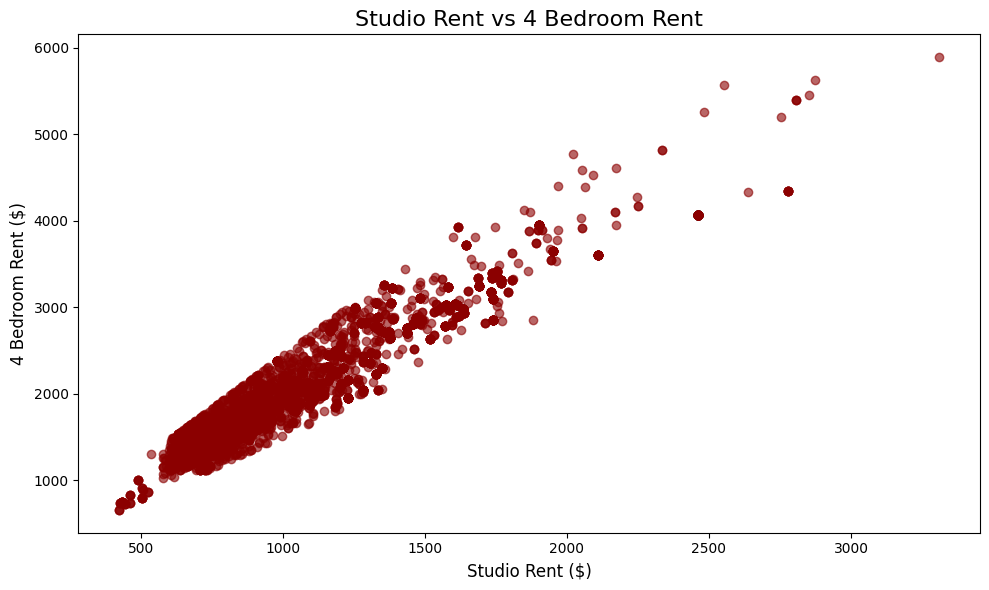

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(county_median26['rent_50_0'], county_median26['rent_50_4'], alpha=0.6, color='darkred')
plt.title('Studio Rent vs 4 Bedroom Rent', fontsize=16)
plt.xlabel('Studio Rent ($)', fontsize=12)
plt.ylabel('4 Bedroom Rent ($)', fontsize=12)
plt.tight_layout()
plt.show()

This graph is comparing the median rent of a 4 bedroom vs a studio. Fromthis graph it seems that in most places that a 4 bedroom rent is double a studio. Most places even fall in the same price range. I want to further explore this by plotting the diferences or making the pointsdifferent colors based on the state.

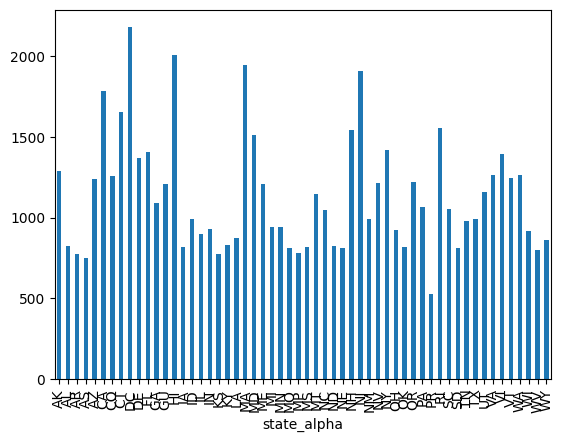

In [7]:
state_rent_1 = county_median26.groupby('state_alpha')['rent_50_1'].mean()

state_rent_1.plot(kind='bar')
plt.show()

This graph is showing the average median rent of a 1 bedroom in each state and territoty. It seemslike there is a good amount of variety amongst them. I want to further explore this with boxplots.